# 02: Surface water storage (SWS) vs GRACE in arid regions

Compare GloLakes lake/reservoir storage anomalies with GRACE TWSA and export the thresholded lake-pixel shapefile used by notebook `03`.

| Item | Value |
|------|-------|
| Products | HydroLAKES polygons + GloLakes absolute ICESat-2 (`v1.0`) |
| Arid mask | Zomer AI <= 0.2 (`data/processed/boundaries/ai_v3_yr_mask_02_pol.shp`) |
| Analysis window | 2004-04-01 to 2025-09-30 |
| Baseline | 2004-2009 mean removed |
| Units | lake volume anomalies in km3; GRACE-window comparison in cm WE |
| Notebook 03 input | thresholded shapefile under `data/raw/sws/shapefiles/` |

Notebook `03` intersects this shapefile with valid recharge-efficiency pixels, then exports final Figure S11 and Table S3.

**Prerequisites:** notebook `01` precip Zarr and GRACE mascons; arid shapefile under `data/processed/boundaries/`.

**FORCE:** `FORCE=True` re-downloads HydroLAKES/GloLakes. `FORCE_REBUILD=True` rebuilds the SWSA batch cache.

**Resources:** download and lake-batch workers auto-sized from CPU (env: `DOWNLOAD_THREADS`, `N_PROCESS_WORKERS`). GPU is not used (I/O + pandas/xarray batch).

Helpers: `src/sws_analysis_utils.py`, `download_data.resolve_grace_paths`.


In [1]:
# Project paths: run with cwd = repository root (or notebooks/ - auto-detected)
from pathlib import Path
import sys
import logging

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    candidate = PROJECT_ROOT.parent
    if (candidate / "src").is_dir():
        PROJECT_ROOT = candidate
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"

logging.basicConfig(level=logging.WARNING, format="%(levelname)s: %(message)s")
print(f"repo: {PROJECT_ROOT}")

%load_ext autoreload
%autoreload 2


repo: .


In [2]:
# Config - adjust window / FORCE only if needed
from sws_analysis_utils import (
    get_resource_config,
    load_sws_config,
    resolve_precip_path,
    run_download_all,
)
from download_data import resolve_grace_paths

ANALYSIS_START = "2004-04-01"
ANALYSIS_END = "2025-09-30"
GLOLAKES_PRODUCT = "absolute_icesat2"
GLOLAKES_VERSION = "v1.0"
SORT_BY = "area"  # "area" or "completeness_pct"
GRACE_WINDOW_DEG = 1.0
LAKE_PCT_THRESHOLD = 20  # Fig S11: lake sigma >= 20% of GRACE sigma
AGGREGATE_BY_GRACE_PIXEL = True

# FORCE=True re-downloads HydroLAKES/GloLakes raw files.
# FORCE_REBUILD=True rebuilds SWSA batch cache under data/raw/sws/processed/.
FORCE = False
FORCE_REBUILD = False

cfg = load_sws_config()
cfg.data_root = RAW_DIR / "sws"
cfg.arid_areas_path = PROCESSED_DIR / "boundaries" / "ai_v3_yr_mask_02_pol.shp"
_grace = resolve_grace_paths(RAW_DIR)
cfg.csr_grace_path = _grace["csr"]
cfg.jpl_grace_path = _grace["jpl"]
cfg.gsfc_grace_path = _grace["gsfc"]
cfg.csr_mask_path = _grace["csr_mask"]
cfg.reference_md = PROJECT_ROOT / "docs" / "SWS_REFERENCE.md"
cfg.analysis_start = ANALYSIS_START
cfg.analysis_end = ANALYSIS_END
cfg.ensure_dirs()

precip_path = resolve_precip_path(
    preferred=str(INTERIM_DIR / "gpm" / "GPM_3IMERGDF_Jan2002_Sep2025_resToM.zarr"),
)
cfg.precip_path = Path(precip_path)

res = get_resource_config()
print(f"period: {ANALYSIS_START} to {ANALYSIS_END}")
print(f"FORCE={FORCE}  FORCE_REBUILD={FORCE_REBUILD}")
print(
    f"resources: download_workers={res['download_workers']}  "
    f"process_workers={res['process_workers']}  gpu={res['gpu']}"
)
print(f"  ({res['gpu_note']})")
print(f"data_root: data/raw/sws")
print(f"precip: data/interim/gpm/{Path(precip_path).name}")


period: 2004-04-01 to 2025-09-30
FORCE=False  FORCE_REBUILD=False
resources: download_workers=15  process_workers=15  gpu=detected_unused
  (lake batch is pandas/xarray/matplotlib; CPU threads only)
data_root: data/raw/sws
precip: data/interim/gpm/GPM_3IMERGDF_Jan2002_Sep2025_resToM.zarr


## 1. Download HydroLAKES + GloLakes

Downloads only what this analysis uses:
1. HydroLAKES polygon shapefile
2. GloLakes absolute ICESat-2 monthly storage NetCDF

Re-runs skip complete files unless `FORCE=True`.


In [3]:
%%time
download_summary = run_download_all(
    cfg, glolakes_version=GLOLAKES_VERSION, force=FORCE
)
# Compact relative summary
for key, val in download_summary.items():
    if isinstance(val, dict):
        for k, path in val.items():
            rel = Path(path).resolve().relative_to(PROJECT_ROOT)
            print(f"  [ok] {key}/{k}: {rel}")
    else:
        rel = Path(val).resolve().relative_to(PROJECT_ROOT)
        print(f"  [ok] {key}: {rel}")


resources: download_workers=15  process_workers=15  gpu=detected_unused (lake batch is pandas/xarray/matplotlib; CPU threads only)
SWS data download (2 steps)
  dir: data/raw/sws/raw/
[1/2] HydroLAKES (global lake polygons)
  [ok] data/raw/sws/raw/hydrolakes/HydroLAKES_polys_v10_shp/HydroLAKES_polys_v10_shp/HydroLAKES_polys_v10.shp
[2/2] GloLakes v1.0 (absolute_icesat2)
  1 GloLakes NetCDF product(s)
  dir: data/raw/sws/raw/glolakes/v1.0/
  [ok] absolute_icesat2
download complete
  [ok] hydrolakes: data/raw/sws/raw/hydrolakes/HydroLAKES_polys_v10_shp/HydroLAKES_polys_v10_shp/HydroLAKES_polys_v10.shp
  [ok] glolakes/absolute_icesat2: data/raw/sws/raw/glolakes/v1.0/Global_Lake_Absolute_Storage_LandsatPlusICESat2 (1984-present).nc
CPU times: user 59.1 ms, sys: 27.5 ms, total: 86.6 ms
Wall time: 3.65 s


In [1]:
# OPTIONAL: reclaim disk space (kept commented on purpose).
# Verifies data/raw/sws/processed/hydrolakes_polygons.parquet is built before deleting
# the ~2.2 GB raw HydroLAKES zip/shapefile. Re-run download_hydrolakes(force=True) later
# if you need the raw shapefile again. GloLakes raw is kept (used directly each run).
# from sws_analysis_utils import remove_hydrolakes_raw
# removed = remove_hydrolakes_raw(cfg)
# print(f"Freed {removed['freed_gb']:.1f} GB")


## 2. Arid lake catalog and SWSA batch

Filter GloLakes lakes whose polygons intersect the arid mask, then build monthly volume anomalies (baseline 2004-2009). Set `MAX_LAKES` to a small integer for a quick test.

Cache lives under `data/raw/sws/processed/glolakes_batch/`. Use `FORCE_REBUILD=True` to ignore the cache.


In [5]:
%%time
from sws_analysis_utils import build_glolakes_arid_catalog, build_glolakes_swsa_batch

arid_catalog = build_glolakes_arid_catalog(
    product=GLOLAKES_PRODUCT,
    version=GLOLAKES_VERSION,
    cfg=cfg,
    sort_by=SORT_BY,
)
print(f"Arid GloLakes lakes: {len(arid_catalog)}")

MAX_LAKES = None       # e.g. 50 for a quick test; None = all
INTERPOLATE = True
INTERP_METHOD = "spline"
INTERP_MAX_GAP = 6
INTERP_EXTRAPOLATE_EDGES = False
USE_CACHE = True

ranked_catalog, volume_series = build_glolakes_swsa_batch(
    product=GLOLAKES_PRODUCT,
    version=GLOLAKES_VERSION,
    cfg=cfg,
    max_lakes=MAX_LAKES,
    sort_by=SORT_BY,
    interpolate=INTERPOLATE,
    interp_method=INTERP_METHOD,
    interp_max_gap=INTERP_MAX_GAP,
    interp_extrapolate_edges=INTERP_EXTRAPOLATE_EDGES,
    use_cache=USE_CACHE,
    force_rebuild=FORCE_REBUILD,
)
print(f"Lakes with volume anomaly: {len(volume_series)}")
ranked_catalog.head(5)


  arid catalog (intersects): 1416 lakes
  [ok] data/raw/sws/catalog/glolakes_arid_absolute_icesat2.csv
Arid GloLakes lakes: 1416
  loaded batch cache (1416 lakes)
  [ok] data/raw/sws/processed/glolakes_batch/absolute_icesat2_v1.0_nall_interp-spline-gap6-noedges_*
Lakes with volume anomaly: 1416
CPU times: user 21.8 s, sys: 3.21 s, total: 25 s
Wall time: 35.3 s


,lake_id,lake_name,country,area_km2,lat,lon,dataset_source,lat_centroid,lon_centroid,completeness_pct
0,1431,Ngangla Ringco,China,498.06,31.572918,83.052086,GloLakes_absolute_icesat2,31.542796,83.077576,63.953488
1,1435,Hamun-E Saberi,Afghanistan,488.53,31.489582,61.297916,GloLakes_absolute_icesat2,31.401149,61.277147,63.953488
2,1308,No Name,Turkmenistan,417.16,41.219166,61.403126,GloLakes_absolute_icesat2,41.166932,61.556859,68.217054
3,995,Musters,Argentina,410.52,-45.559723,-69.143753,GloLakes_absolute_icesat2,-45.414659,-69.195888,64.728682
4,978,Los Barreales,Argentina,395.81,-38.578674,-68.688972,GloLakes_absolute_icesat2,-38.544934,-68.816980,78.294574


## 3. GRACE mean + precipitation on the GRACE grid

Requires GRACE NetCDFs under `data/raw/grace/` and the monthly precip Zarr from notebook `01`. Time index is month-end.


In [6]:
%%time
from sws_analysis_utils import build_grace_time_range, process_grace_mean, process_precip_on_grace_grid

time_range = build_grace_time_range(cfg)
grace_mean = process_grace_mean(cfg, time_range=time_range)
precip_gridded = process_precip_on_grace_grid(
    grace_mean, cfg, precip_path=precip_path, time_range=time_range
)
print(f"GRACE mean: {dict(grace_mean.sizes)} | Precip: {dict(precip_gridded.sizes)}")


  GRACE: data/raw/grace/csr/CSR_GRACE_GRACE-FO_RL0603_Mascons_all-corrections.nc
  land mask: data/raw/grace/csr/CSR_GRACE_GRACE-FO_RL06_Mascons_v02_LandMask.nc
  found land mask variable: LO_val
  Applying land mask to exclude ocean pixels...
  Masked 671474 ocean pixels (set to NaN)
  Coarsening by 4×4 to 1-degree resolution...
  Coarsened grid: 64800 total pixels, 21242 pure-land, 43558 ocean-contaminated (excluded)
  GRACE: data/raw/grace/jpl/GRCTellus.JPL.200204_202605.GLO.RL06.3M.MSCNv04CRI.nc
Loading land mask from GRACE data file
  Applying land mask to exclude ocean pixels...
  Masked 173288 ocean pixels (set to NaN)
  Coarsening by 2×2 to 1-degree resolution...
  Coarsened grid: 64800 total pixels, 20197 pure-land, 44603 ocean-contaminated (excluded)
  GRACE: data/raw/grace/gsfc/gsfc.glb_.200204_202603_rl06v2.0_obp-ice6gd_halfdegree.nc
Loading land mask from GRACE data file
  Applying land mask to exclude ocean pixels...
  Masked 173420 ocean pixels (set to NaN)
  Coarsening 

## 4. SWS filtering and Figure S11 input

Aggregate lakes to GRACE pixels (`GRACE_WINDOW_DEG=1`) and retain pixels where lake std >= 20% of GRACE std. This section exports:
- the thresholded point shapefile consumed by notebook `03`
- comparison JPEGs only for threshold-passing pixels when `SAVE_FIGURES=True`

Notebook `03` applies the valid recharge-efficiency intersection and exports final Figure S11 and Table S3.


  GRACE pixel summaries (678 pixels, 1416 lakes)


  GRACE pixels:   0%|          | 0/678 [00:00<?, ?pixel/s]

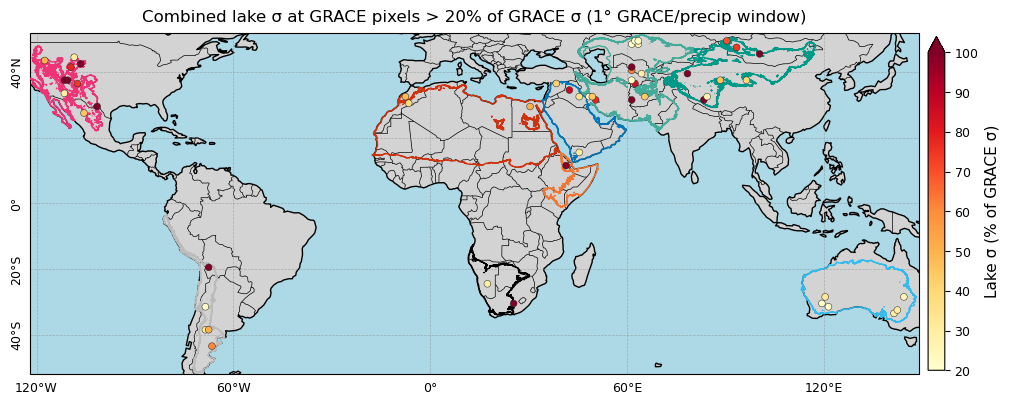

  53 GRACE pixels with lake std > 20% of GRACE (sorted high to low)


src/sws_analysis_utils.py:3886: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(save_path)
site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lake_std_cm' to 'lake_std_c'
  ogr_write(
site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'grace_std_cm' to 'grace_std_'
  ogr_write(


  [ok] data/raw/sws/shapefiles/lake_std_ratio_grace_pixel_win1_thr20.shp
  saving 53 comparison figure(s)
  dir: data/raw/sws/figures/


  Saving figures:   0%|          | 0/53 [00:00<?, ?fig/s]

  [ok] 53 figures in data/raw/sws/figures/
SWS-qualified grace_pixel rows: 53
CPU times: user 1min 48s, sys: 27.8 s, total: 2min 16s
Wall time: 2min 10s


In [7]:
%%time
from sws_analysis_utils import (
    analyze_lake_grace_comparisons,
    export_lake_std_ratio_shapefile,
    load_arid_domains,
    plot_lake_std_ratio_map,
    save_lake_grace_comparison_figures,
)

# Save comparison JPEGs only for pixels that pass LAKE_PCT_THRESHOLD.
SAVE_FIGURES = False
SUMMARY_MODE = "grace_pixel" if AGGREGATE_BY_GRACE_PIXEL else "per_lake"
stem = f"lake_std_ratio_{SUMMARY_MODE}_win{int(GRACE_WINDOW_DEG)}_thr{LAKE_PCT_THRESHOLD}"

lake_summary, _ = analyze_lake_grace_comparisons(
    ranked_catalog,
    volume_series,
    grace_mean,
    precip_gridded,
    cfg=cfg,
    window_deg=GRACE_WINDOW_DEG,
    aggregate_by_grace_pixel=AGGREGATE_BY_GRACE_PIXEL,
    save_figures=False,
    calculate_residual=True,
    parallel=True,
)

filtered_lake_std = plot_lake_std_ratio_map(
    lake_summary,
    ranked_catalog,
    volume_series=volume_series,
    grace_da=grace_mean,
    cfg=cfg,
    summary_mode=SUMMARY_MODE,
    window_deg=GRACE_WINDOW_DEG,
    domains_gdf=load_arid_domains(cfg=cfg),
    draw_domain_boundaries=True,
    figsize=(10, 4),
    vmax=100,
    point_size=24,
    min_pct=LAKE_PCT_THRESHOLD,
    filter_mode="anomaly",
    return_table=True,
    show=True,
)

export_lake_std_ratio_shapefile(
    filtered_lake_std,
    summary_mode=SUMMARY_MODE,
    save_path=cfg.shapefiles_dir / f"{stem}.shp",
)

if SAVE_FIGURES:
    saved_figs = save_lake_grace_comparison_figures(
        filtered_lake_std,
        ranked_catalog,
        volume_series,
        grace_mean,
        precip_da=precip_gridded,
        cfg=cfg,
        window_deg=GRACE_WINDOW_DEG,
        parallel=True,
        aggregate_by_grace_pixel=AGGREGATE_BY_GRACE_PIXEL,
    )

print(f"SWS-qualified {SUMMARY_MODE} rows: {len(filtered_lake_std)}")
